## Chapter 13

## Aldrin Example

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

Read in the data

In [21]:
aldrin = pd.read_csv('aldrin.csv')
aldrin['depth'] = pd.Categorical(aldrin['depth'], categories=['bottom', 'middepth', 'surface'], ordered=True)
aldrin.head()

,aldrin,depth
0,3.8,bottom
1,4.8,bottom
2,4.9,bottom
3,5.3,bottom
4,5.4,bottom


Plot the data

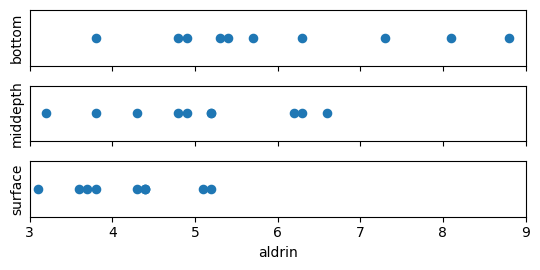

In [22]:
groups = ['bottom', 'middepth', 'surface']
fig, axes = plt.subplots(3, 1, figsize=(5.5, 2.8), sharex=True)

for ax, g in zip(axes, groups):
    x = aldrin.loc[aldrin['depth'] == g, 'aldrin'].to_numpy()
    y = np.ones_like(x)
    ax.scatter(x, y, s=35)
    ax.set_ylabel(g)
    ax.set_yticks([])
    ax.set_xlim(3, 9)

axes[-1].set_xlabel('aldrin')
fig.tight_layout()
fig.savefig('dotplot.png', bbox_inches='tight')
plt.show()

### Fit a Regression Model with a Categorical Variable

We fit the model:
$\texttt{aldrin} \sim C(\texttt{depth})$

This treats depth as a categorical variable and creates indicator (dummy) variables:
$Y = \beta_0 + \beta_1 I(\text{middepth}) + \beta_2 I(\text{surface}) + \varepsilon$

Interpretation:
- $\beta_0$ = mean for bottom (baseline group)
- $\beta_1$ = difference between middepth and bottom
- $\beta_2$ = difference between surface and bottom

Thus, the model is estimating the mean for each group.


,df,sum_sq,mean_sq,F,PR(>F)
C(depth),2.0,16.960667,8.480333,6.13381,0.006367
Residual,27.0,37.329000,1.382556,NaN,NaN
